In [2]:
#mlp model
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

digits=load_digits()
x=digits.data
y=digits.target

#splitting data
xtrain, xtest, ytrain, ytest=train_test_split(x, y, test_size=0.2, random_state=42) #extra param 

mlp=MLPClassifier(hidden_layer_sizes=(32,), max_iter=1000, random_state=42)  #training
mlp.fit(xtrain,ytrain)

trainP=mlp.predict(xtrain)  #predictions
testP=mlp.predict(xtest)

trainA=accuracy_score(trainP,ytrain)
testA=accuracy_score(testP,ytest)
print("Training Accuracy: ",trainA)
print("Testing Accuracy: ",testA)

Training Accuracy:  1.0
Testing Accuracy:  0.9777777777777777


In [3]:
#log reg
from sklearn.linear_model import LogisticRegression

logReg=LogisticRegression(max_iter=1000, random_state=42)
logReg.fit(xtrain,ytrain)

trainP1=logReg.predict(xtrain)
testP1=logReg.predict(xtest)

trainA1=accuracy_score(trainP1,ytrain)
testA1=accuracy_score(testP1,ytest)
print("Training Accuracy: ",trainA1)
print("Testing Accuracy: ",testA1)

Training Accuracy:  1.0
Testing Accuracy:  0.975


In [4]:
print("Model Comparison:")
print()
print(f"MLP Training Accuracy: {trainA:.4f}")
print(f"MLP Testing Accuracy:  {testA:.4f}")
print()
print(f"Logistic Regression Training Accuracy: {trainA1:.4f}")
print(f"Logistic Regression Testing Accuracy:  {testA1:.4f}")

Model Comparison:

MLP Training Accuracy: 1.0000
MLP Testing Accuracy:  0.9778

Logistic Regression Training Accuracy: 1.0000
Logistic Regression Testing Accuracy:  0.9750


In [5]:
mgap=trainA-testA
lgap=trainA1-testA1
print(f"MLP Overfitting Gap: {mgap:.4f}")
print(f"Logistic Regression Overfitting Gap: {lgap:.4f}")

MLP Overfitting Gap: 0.0222
Logistic Regression Overfitting Gap: 0.0250


In [3]:
import pandas as pd
layers=[(8,),(32,),(128,),(64,32)]
result=[]
for l in layers:
    mlp=MLPClassifier(hidden_layer_sizes=l, max_iter=1000, random_state=42)
    mlp.fit(xtrain,ytrain)

    trainP=mlp.predict(xtrain)  #predictions
    testP=mlp.predict(xtest)
    
    trainA=accuracy_score(trainP,ytrain)
    testA=accuracy_score(testP,ytest)

    result.append([l,trainA,testA])

result_df = pd.DataFrame(result,columns=["Hidden Layers","Train Accuracy","Test Accuracy"])
print(result_df)
'''larger model does not always improve test accuracy'''

  Hidden Layers  Train Accuracy  Test Accuracy
0          (8,)             1.0       0.944444
1         (32,)             1.0       0.977778
2        (128,)             1.0       0.977778
3      (64, 32)             1.0       0.966667


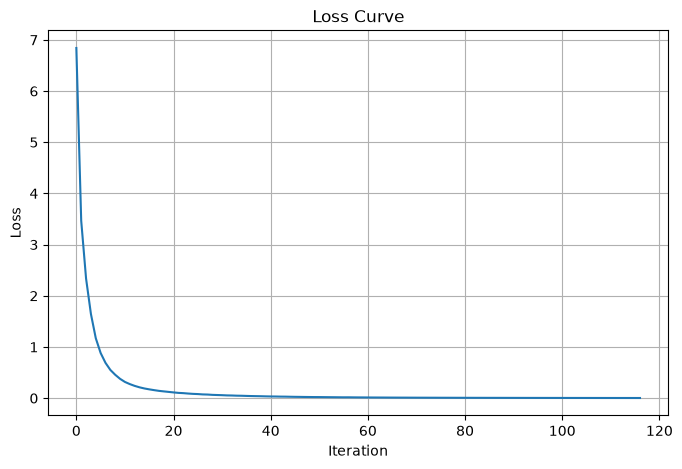

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(mlp.loss_curve_)
plt.title("Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)

plt.show()